# Develop quick stuff

For temporary/quick stuff to be developed

In [1]:
import os
import sys

base_path = os.path.abspath("./..")
thesis_path = os.path.join(base_path, "thesis")
for p in [base_path, thesis_path]:
  if p not in sys.path:
      sys.path.append(p)

from IPython.display import display, Markdown
import torch


from experiments.acceptance_loop_cv_based_MNAR import THRESHOLD_BASIS, METRIC_CATEGORIES, EXPECTATION_TYPES, REAL_PERFORMANCE_TYPES
from berebasl.simulation.credit_data_simulation import CreditDataGenerator, GaussianMixture

In [3]:
os.chdir(base_path)
%run "thesis/helper_scripts/general.py"

In [4]:
os.chdir(thesis_path)


grid_path = os.path.abspath('../berebasl/data/simulations/mnar_grid_hyp_vec')
grid_biases = extract_biases_from_dirnames(grid_path)

all_sim_objs = extract_all_sim_objs_vec(grid_path, grid_biases)
all_corrs = torch.stack([sim_objs['corr_to_hidden'] for sim_objs in all_sim_objs.values()], dim=0)
assert torch.all(all_corrs[[0]] == all_corrs)

base_sim_bias = '0_0'
base_sim = all_sim_objs[base_sim_bias]
wished_corr = -0.4
base_sim_objs = slice_vec_sim(base_sim, wished_corr)

base_dgp_unsliced = base_sim["data_generator"]
dgp_base = base_sim_objs["data_generator"]

In [4]:
from berebasl.simulation.credit_data_simulation import CreditData
credit_data: CreditData = base_sim["credit_data"]

In [12]:
from berebasl.estimation.classifiers import BatchedLogistic
from copy import deepcopy

all_threshold_lbls = [th + '_' + m for th in THRESHOLD_BASIS for m in METRIC_CATEGORIES]

for str_bias, sim_objs in all_sim_objs.items():
    credit_data: CreditData = deepcopy(sim_objs["credit_data"])
    acc_flags_per_th_alternative = {k: v.clone() for k, v in sim_objs["alternative_accepted"].items()}
    lbl_acc_flag_in_data = set(all_threshold_lbls) - set(acc_flags_per_th_alternative.keys())
    assert len(lbl_acc_flag_in_data) == 1
    lbl_acc_flag_in_data = next(lbl_acc_flag_in_data.__iter__())

    betas_per_acc = {}

    for acc_k in [lbl_acc_flag_in_data] + list(acc_flags_per_th_alternative.keys()):
        if acc_k != lbl_acc_flag_in_data:
            credit_data.change_acceptance_flag(acc_flags_per_th_alternative[acc_k])

        feats, lbls, mask_valid, gen_round = credit_data.accepts(include_gen_round=True, include_mask_valid=True)
        G = credit_data.last_gen_round+1
        Co, N, F = feats.shape

        feats = feats.unsqueeze(1).expand(Co, G, N, F)
        lbls = lbls.unsqueeze(1).expand(Co, G, N)

        arange_G = torch.arange(G, device=gen_round.device, dtype=gen_round.dtype)

        mask_gen_round_ok = gen_round.unsqueeze(1) <= arange_G.view(1, G, 1)

        mask_valid_and_gen_round_ok = mask_valid.unsqueeze(1) & mask_gen_round_ok


        batched_lr = BatchedLogistic(n_features=F-1, batch_shape = lbls.shape[:-1], device=feats.device, dtype=feats.dtype)
        model_vars = [f for f in range(F) if f != (sim_objs["var_to_hide"] % F)]
        print("Starting training", str_bias, acc_k)
        batched_lr.fit(feats[..., model_vars].clone(), lbls.clone(), mask_valid_obs=mask_valid_and_gen_round_ok)
        betas_per_acc[acc_k] = batched_lr.beta.squeeze(-1)

    torch.save(betas_per_acc, os.path.join(grid_path, 'bias_' + str_bias, "betas_per_acc_and_gen.pt"))



Starting training 0_0 acc_based_roc
Starting training 0_0 oracle_ks
Starting training 0_0 oracle_roc
Starting training 0_0 acc_based_ks
Starting training 0_05 acc_based_roc
Starting training 0_05 oracle_ks
Starting training 0_05 oracle_roc
Starting training 0_05 acc_based_ks
Starting training 0_1 acc_based_roc
Starting training 0_1 oracle_ks
Starting training 0_1 oracle_roc
Starting training 0_1 acc_based_ks
Starting training 0_2 acc_based_roc
Starting training 0_2 oracle_ks
Starting training 0_2 oracle_roc
Starting training 0_2 acc_based_ks
Starting training 0_35 acc_based_roc
Starting training 0_35 oracle_ks
Starting training 0_35 oracle_roc
Starting training 0_35 acc_based_ks


In [11]:
os.path.exists(os.path.join(grid_path, 'bias_' + str_bias))

True

In [8]:
grid_path

'/home/RDC/ordonezm/BEReBASL/berebasl/data/simulations/mnar_grid_hyp_vec'

In [10]:
os.listdir(grid_path)

['bias_0_0', 'bias_0_05', 'bias_0_1', 'bias_0_2', 'bias_0_35']

In [9]:
str_bias

'0_0'

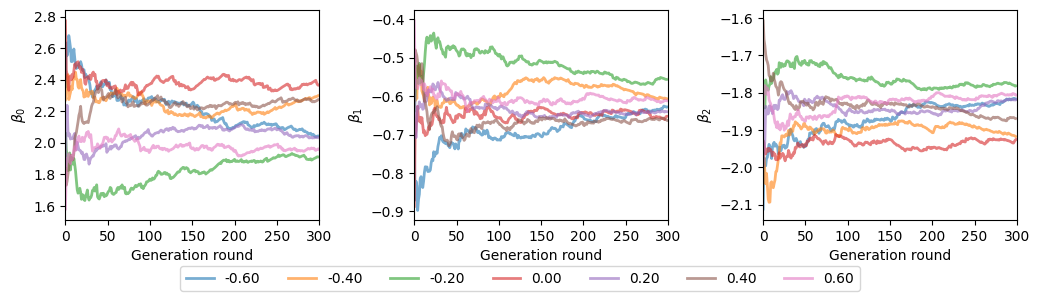

In [38]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection

alpha = 0.6
y_offset_mul = 0.05
linewidth = 2
corr_to_hidden = sim["corr_to_hidden"]

Co, G, K = beta.shape


fig, axes = plt.subplots(1, K, figsize=(3.5*K, 3))
#fig.subplots_adjust(bottom=0.2)
cmap = plt.get_cmap("tab10")
colors = [cmap(i)[:3] + (alpha,) for i in range(Co)]


for k in range(K):
    ax = axes[k]
    beta_k = beta[:, :, k]          # [Co, G]
    gen_round = torch.arange(G)

    # Build segments for LineCollection
    segments = [torch.stack([gen_round, beta_k[co]], dim=-1) for co in range(Co)]
    lc = LineCollection(segments, colors=colors, linewidths=linewidth)

    ax.add_collection(lc)
    ax.set_xlim(0, G-1)
    min_beta, max_beta = beta_k.min().item(), beta_k.max().item()
    add_rest_beta = y_offset_mul * (max_beta - min_beta)
    ax.set_ylim(min_beta - add_rest_beta, max_beta + add_rest_beta)

    #ax.set_title(f"K = {k}")
    ax.set_ylabel(f"$\\beta_{{{k}}}$")
    ax.set_xlabel("Generation round")
    #ax.grid(True)


handles_corrs = [Line2D([0], [0], linewidth=linewidth, color=c) for c in colors]
labels_corrs = [f"{corr.item():.2f}" for corr in corr_to_hidden]


plt.tight_layout()
fig.subplots_adjust(bottom=0.25)
fig.legend(
    handles_corrs,
    labels_corrs,
    ncol=len(handles_corrs),
    loc="lower center"
)

plt.show()


(tensor(2.7834, dtype=torch.float64), tensor(-2.1152, dtype=torch.float64))